# Dimensionality reduction and clustering

**Day 2 morning — Introduction to Machine Learning for Text Analysis with Python**

<img src="../images/02_tokenization.png" alt="Tokenization brick" style="max-width: 130px;"> <img src="../images/03_vectorization.png" alt="Vectorization brick" style="max-width: 130px;"> <img src="../images/04_dimred_cluster.png" alt="Dimensionality reduction and clustering brick" style="max-width: 130px;">

In supervised learning (tomorrow) we possess labelled examples and train a model to predict those labels. 

In **unsupervised learning** we give the machine no labels at all and ask it to find structure in the texts on its own. This is very useful for rich and exploratory analysis of your data. 

We will work through two classic unsupervised building blocks:

1. **Dimensionality reduction** with `PCA` — grouping similar features together. 
2. **Clustering** with `K-means` — grouping similar documents together.

The example dataset we will use is the **20 Newsgroups** collection introduced in the pre-work. This contains around 18,000 posts from 20 Usenet discussion groups (from the 1990's, pre-social media, US-dominated internet). The newsgroup each post came from is actually recorded in the dataset (i.e., the data *is* labeled), but we will intentionally *hide* that information from our models and work purely inductively, letting structure emerge from the texts alone. At the end of the notebook we will reveal the labels and check how much of the newsgroup organisation our methods recovered.

## 0. Setup

In [1]:
# --- Import libraries ---
# numerical and data handling
import numpy as np                                      # arrays and math operations
import pandas as pd                                      # tables (DataFrames) for summarising results

# visualisation
import matplotlib.pyplot as plt                          # the base plotting library
import seaborn as sns                                    # builds on matplotlib with nicer defaults

# the dataset and an evaluation metric
from sklearn.datasets import fetch_20newsgroups          # downloads the 20 Newsgroups text collection
from sklearn.metrics import adjusted_rand_score          # measures how well clusters match true labels

# text to numbers (Day 1 recap!)
from sklearn.feature_extraction.text import TfidfVectorizer  # turns raw text into TF-IDF vectors

# today's two unsupervised techniques
from sklearn.decomposition import PCA                    # Principal Component Analysis (dim. reduction)
from sklearn.cluster import KMeans                       # K-means (clustering)

# a helper we need in section 4.2
from sklearn.preprocessing import Normalizer             # rescales each row to unit length

# --- Reproducibility ---
# A fixed random seed makes results identical on every run.
# e.g. KMeans(..., random_state=SEED).
SEED = 42

## 1. Preprocess the data 

<img src="../images/01_preprocessing.png" alt="Preprocessing brick" style="max-width: 130px;">

As in the prework notebook, we remove headers, footers and quoted replies. Those 'leak' metadata (the newsgroup name itself often appears in the header!) that would make the task artificially easy.

In [2]:
# --- Load the dataset ---
# We fetch all 20 newsgroups (both the official train and test portions).
# Since we are doing unsupervised learning today, we have no need for that split.
# We also strip headers, footers, and quoted replies because they contain metadata
# (like the newsgroup name itself) that would make the task artificially easy.
newsgroups = fetch_20newsgroups(
    subset='all',                                # get all posts, not just train or test
    remove=('headers', 'footers', 'quotes'),     # strip metadata that would leak the answer
    random_state=SEED,                           # fix the shuffle order for reproducibility
)

# --- Filter out near-empty posts ---
# After the stripping, some posts have almost nothing left. We keep only posts
# with more than 50 characters of content, and keep each post's label with it.
docs = []                                        # will hold the texts we keep
labels = []                                      # will hold the matching newsgroup labels
for doc, label in zip(newsgroups.data, newsgroups.target):  # walk through posts and labels together
    if len(doc.strip()) > 50:                    # long enough?
        docs.append(doc)                         # keep the text
        labels.append(label)                     # keep its label (a number, 0-19)

labels = np.array(labels)                        # as a numpy array, for easy comparisons later
label_names = newsgroups.target_names            # the 20 newsgroup names (e.g. 'sci.space')

# --- Quick summary ---
print(f"Number of posts: {len(docs)}\n")
print("Posts per newsgroup:")
print(pd.Series([label_names[l] for l in labels]).value_counts())  # count posts per newsgroup name


Number of posts: 17886

Posts per newsgroup:
soc.religion.christian      969
comp.sys.ibm.pc.hardware    952
comp.windows.x              952
sci.med                     948
rec.sport.hockey            946
sci.crypt                   943
sci.space                   941
sci.electronics             940
misc.forsale                933
comp.os.ms-windows.misc     932
comp.graphics               930
rec.motorcycles             926
rec.sport.baseball          916
comp.sys.mac.hardware       910
rec.autos                   905
talk.politics.mideast       887
talk.politics.guns          871
alt.atheism                 760
talk.politics.misc          740
talk.religion.misc          585
Name: count, dtype: int64


Look at the composition before going on. Several groups are likely close neighbours in terms of content — five `comp.*` groups about computing, four `rec.*` groups about hobbies, three religion-related groups, `talk.politics.guns` and `talk.politics.misc`. 

In [3]:
# --- Inspect a single post ---
# Always look at your data before doing anything with it!
# Here we print the first post in our filtered collection to get a feel for what
# these texts look like after the headers/footers/quotes have been removed.
print("Newsgroup:", label_names[labels[0]])  # look up the newsgroup name for the first post's label
print("-" * 40)                              # print a visual separator line
print(docs[0][:1000])                        # print the first 1000 characters of the first post

Newsgroup: rec.sport.hockey
----------------------------------------


I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killing those Devils worse than I thought. Jagr just showed you why
he is much better than his regular season stats. He is also a lot
fo fun to watch in the playoffs. Bowman should let JAgr have a lot of
fun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final
regular season game.          PENS RULE!!!




## 2. From text to numbers

<img src="../images/02_tokenization.png" alt="Tokenization brick" style="max-width: 130px;"> <img src="../images/03_vectorization.png" alt="Vectorization brick" style="max-width: 130px;">

Yesterday afternoon we saw three ways of representing text as numbers. This morning we use a **bag of words**, weighting features using TF-IDF. Under the hood this vectorizer first **tokenizes** each post, splitting the raw text into individual words. As a quick reminder, TF-IDF counts how often each word appears in a document (term frequency) and then scales those counts *down* for words that appear in many documents (inverse document frequency). 

In [4]:
# --- Build a TF-IDF document-term matrix ---
# Each document becomes a row of 24k numbers — one per word in the vocabulary.
# The value in each cell reflects how important that word is to that document.
vectorizer = TfidfVectorizer(
    stop_words='english',  # remove very common stop words (the, and, of, ...)
    min_df=5,           # drop words appearing in fewer than 5 documents (very rare words)
    max_df=0.9,      # drop words appearing in more than 95% of documents (very common words)
)

# fit_transform does two things at once:
#   fit    = learn the vocabulary from our documents (basically, create a list of unique words)
#   transform = convert each document into a TF-IDF vector using that vocabulary (of length 21k).
X_tfidf = vectorizer.fit_transform(docs)

# the shape is (number of documents, number of words in vocabulary)
print(f"Shape of our document-term matrix: {X_tfidf.shape}")
print(f"So each of the {X_tfidf.shape[0]} posts is now a point in {X_tfidf.shape[1]}-dimensional space.")

Shape of our document-term matrix: (17886, 24146)
So each of the 17886 posts is now a point in 24146-dimensional space.


## 3. Dimensionality reduction with PCA

<img src="../images/04_dimred_cluster.png" alt="Dimensionality reduction and clustering brick" style="max-width: 130px;">

Each post is now a point in a 21k-dimensional space. Relatively few of those dimensions will be non-zero (i.e., sparse). This is where dimensionality reduction comes in.

**How PCA works.** Principal Component Analysis builds a new, much smaller set of dimensions. Each new dimension (a *principal component*) is a weighted combination of the original word features, with these components are constructed in order of importance. The first component points in the direction along which the documents vary the most; the second captures the most remaining variation while being uncorrelated with the first; and so on. 

Instead of 21k word counts per document, we can keep just the first 100 components and retain much of what distinguishes the documents from one another.

Loosely, each component is a bundle of words that rise and fall together across the collection. Below we inspect each component's top words to see whether these bundles are interpretable.

One practical note. PCA needs an ordinary ("dense") matrix, so we first convert our document-term matrix from its memory-saving sparse format. This is fine at our size; for much larger corpora you would use `TruncatedSVD`, a close cousin of PCA that works on sparse data directly.

In [ ]:
# --- Run PCA to reduce from 24,146 dimensions to 100 ---
# PCA finds the directions along which documents vary the most, and keeps only
# those. We go from 24,146 word-features down to 100 "principal components".
# This makes downstream steps faster and removes noise.

# Step 1: convert from sparse to dense format.
# TF-IDF gives us a "sparse" matrix (only non-zero values are stored; memory efficient).
# PCA needs a regular "dense" matrix (every value is stored; less memory efficient).
X_dense = X_tfidf.toarray()  # shape: (17886, 24146)

# Step 2: create the PCA object, asking for the first 100 components. 
# (Uncorrelated components are guaranteed to be ordered by how much variation they explain.)
pca = PCA(n_components=100, random_state=SEED)

# Step 3: fit PCA to the data and transform in one step.
# After this, each document is described by 100 numbers instead of 24,146. 
# (Variance explained is quite low but we will see that it is enough to get good clustering results.)
X_pca = pca.fit_transform(X_dense)  # shape: (17886, 100)

print(f"Before PCA: {X_dense.shape}")   # (documents, original word features)
print(f"After PCA:  {X_pca.shape}")     # (documents, principal components)
# How much of the original variation did we keep?
print(f"Share of total variance kept by these 100 components: {pca.explained_variance_ratio_.sum():.0%}")

Before PCA: (17886, 24146)
After PCA:  (17886, 100)
Share of total variance kept by these 100 components: 10%


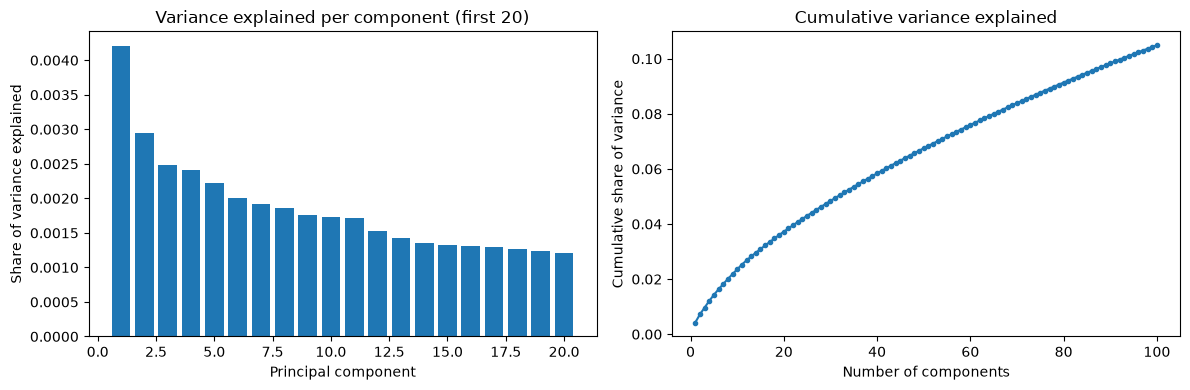

In [6]:
# --- Visualise how variance is spread across components ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))  # create two side-by-side subplots

# Left plot: variance explained by each of the first 20 components individually
ax1.bar(range(1, 21), pca.explained_variance_ratio_[:20])  # bar chart of per-component variance
ax1.set_xlabel('Principal component')
ax1.set_ylabel('Share of variance explained')
ax1.set_title('Variance explained per component (first 20)')

# Right plot: cumulative variance — how much total variance is kept as we add components
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)  # running total across components
ax2.plot(range(1, 101), cumulative_variance, marker='.')        # line plot with dot markers
ax2.set_xlabel('Number of components')
ax2.set_ylabel('Cumulative share of variance')
ax2.set_title('Cumulative variance explained')

plt.tight_layout()  # adjust spacing so labels don't overlap
plt.show()

The pattern in the left plot is typical for PCA on a BoW which has low 'instrinsic dimensionality' relative to the high number of dimensions. The first few components carry noticeably more information than the rest, followed by a long tail of components that each add (relatively) less. There is no single "correct" number of components. However, even though 10% explained variance seems low, we must remember that due to the extremely sparse nature of the BoW model vector space, much of this is noise. 

Now for something we can only do because this dataset comes with labels. Let's plot every document on the **first two components**. Twenty colours would be unreadable, so we highlight four newsgroups with distinctive vocabularies and show the other sixteen in grey. Remember, PCA never saw these labels. If the highlighted colours occupy different regions even partly, PCA has found topical structure on its own.

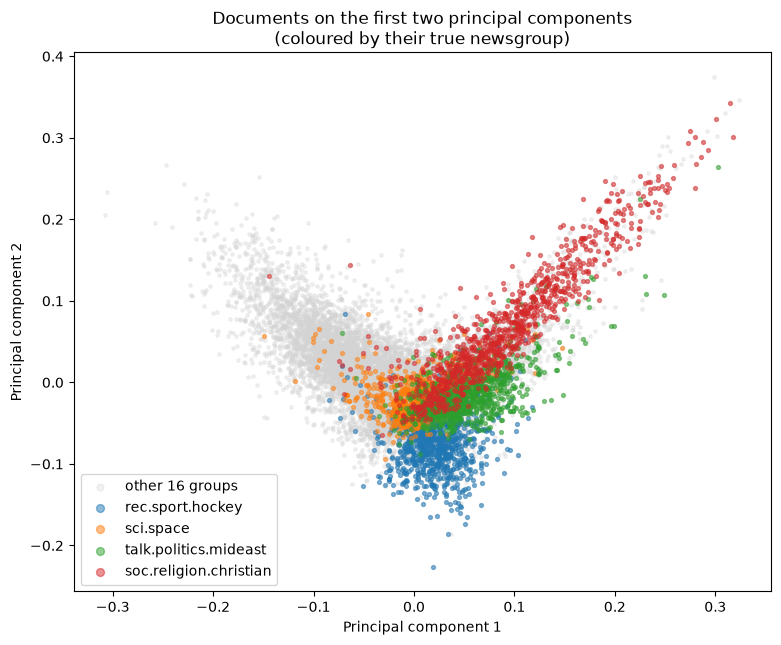

In [8]:
# --- Scatter plot: documents on the first two principal components ---
# We plot every document as a dot, positioned by its first two component scores.
# PCA did not see the newsgroup labels, so if the coloured groups occupy distinct
# regions, that means PCA found existing topical structure on its own. 
# We highlight four groups with distinctive vocabularies; the other 16 are grey.
# 

highlight = ['rec.sport.hockey', 'sci.space', 'talk.politics.mideast', 'soc.religion.christian']

plt.figure(figsize=(9, 7))

# First: plot ALL documents in light grey as a background layer
plt.scatter(X_pca[:, 0], X_pca[:, 1],  # x = component 1, y = component 2
            s=6, alpha=0.3, color='lightgrey', label='other 16 groups')

# Then: overlay the four highlighted newsgroups, each in its own colour
for name in highlight:
    group_index = label_names.index(name)  # find this newsgroup's numeric label (e.g. 0, 1, ... 19)
    mask = labels == group_index           # True for every document that belongs to this group
    plt.scatter(X_pca[mask, 0],            # x-coordinates of just those documents
                X_pca[mask, 1],            # y-coordinates of just those documents
                s=8, alpha=0.5, label=name)

plt.xlabel('Principal component 1')
plt.ylabel('Principal component 2')
plt.title('Documents on the first two principal components\n(coloured by their true newsgroup)')
plt.legend(markerscale=2)  # make the legend dots bigger so they're readable
plt.show()

There is visible structure, but also plenty of overlap. Keep in mind that these two axes hold only a small share of the total variance (check the bar plot above), so documents that look mixed here may be well separated along other components.

Since each component is just a weighted combination of words, we can also ask which words weigh most heavily on each component. This is how you *interpret* what PCA has found.

In [ ]:
# --- Interpret PCA components by their top words ---
# Each principal component is a weighted combination of the original 21k words.
# The words with the highest weights give a first sense of what a component "means".
#(vector is the weight of each word in the vocabulary for that component. We can see which words are most important for each 
# component by looking at the largest weights. This is just what the axis look like and we plot it onedimensional but we need to see 
# components in more dimensions. This is not yet a clustering but we can see that the components are meaningful and we can see which words 
# are important for each component.)

# the word behind each column of the document-term matrix
feature_names = vectorizer.get_feature_names_out()   # array of 21k word strings

def top_terms(weights, feature_names, n=8):
    """Return the n words with the highest weights, as one comma-separated string.

    Works for both PCA components and K-means cluster centres, since both
    are arrays with one weight per word in the vocabulary.
    """
    order = weights.argsort()                        # word positions, sorted smallest weight first
    top_idx = order[::-1][:n]                        # reverse to largest-first, keep the first n
    top_words = [feature_names[i] for i in top_idx]  # look up the actual words
    return ", ".join(top_words)                      # join into one readable string

# Print the top words for the first 8 components.
# A component's weights can be positive or negative; for a first impression
# we look at the words with the largest positive weights.
for i in range(8):
    variance = pca.explained_variance_ratio_[i]      # share of variance this component explains
    print(f"Component {i+1} ({variance:.1%} of variance): {top_terms(pca.components_[i], feature_names)}")


Component 1 (0.4% of variance): god, people, jesus, think, don, believe, say, did
Component 2 (0.3% of variance): god, windows, does, know, dos, jesus, people, file
Component 3 (0.2% of variance): god, jesus, thanks, christ, bible, sin, edu, faith
Component 4 (0.2% of variance): drive, scsi, ide, hard, controller, drives, card, disk
Component 5 (0.2% of variance): game, windows, games, team, don, dos, think, year
Component 6 (0.2% of variance): thanks, know, mail, does, advance, like, don, info
Component 7 (0.2% of variance): key, game, god, chip, encryption, clipper, games, keys
Component 8 (0.2% of variance): edu, geb, pitt, dsl, cadre, n3jxp, chastity, skepticism


## 4. Clustering with K-means


**How K-means works.** You specify the number of clusters, *k*, in advance. The algorithm then:

1. places *k* centres at random positions in the feature space;
2. assigns every document to its nearest centre;
3. moves each centre to the average position of the documents assigned to it;
4. repeats steps 2 and 3 until the assignments stop changing.

The result is *k* groups of documents, each group gathered around a centre. Two things follow from this design. First, *we* must choose *k*; the algorithm will happily produce any number of clusters we ask for, sensible or not. Second, the starting positions are random (by default), so results can differ between runs (scikit-learn reruns the algorithm `n_init` times and keeps the best result, which helps).

### 4.1 Clustering the raw TF-IDF vectors

K-means does not require dimensionality reduction; it can run directly on our 21k-dimensional TF-IDF matrix. Let's do that first. Since the collection's own documentation tells us there are 20 newsgroups, `k=20` is the natural first try.

In [ ]:
# --- Run K-means on the raw TF-IDF vectors ---
# K-means groups documents into k clusters by placing k centres in the feature space
# and assigning each document to its nearest centre, iterating until stable.
# Here we try k=20 since we know the dataset has 20 newsgroups.
# (The words that are shared by many documents will fall into one cluster, and the words that are unique to a few documents will fall into other clusters.)
# (k-means is too basic to be able to find the clusters in this high-dimensional space, but we will see that it works better after PCA.)
km_raw = KMeans(
    n_clusters=20,       # number of clusters to create
    n_init=10,           # run the algorithm 10 times with different starting positions, keep the best
    random_state=SEED,   # for reproducibility
)
clusters_raw = km_raw.fit_predict(X_tfidf)  # fit K-means and return each document's cluster label (0–19)

# How many documents ended up in each cluster?
# If K-means recovered the newsgroups perfectly, we'd expect ~900 per cluster.
print("Documents per cluster:")
print(pd.Series(clusters_raw).value_counts().sort_index())  # count documents per cluster, sorted by cluster number

Documents per cluster:
0      488
1      641
2       73
3     6457
4      527
5      790
6      175
7      984
8      408
9      397
10     286
11     410
12     515
13     542
14     545
15     968
16     218
17    1329
18     262
19    1871
Name: count, dtype: int64


Look at the cluster sizes. Recovering the newsgroups would mean 20 clusters of roughly 900 documents each; instead some are huge and some tiny. To see what a cluster *means*, we use the PCA trick again: each cluster centre is a point in word-space, so we read off the words on which it scores highest.

In [11]:
# --- Interpret clusters by their top words ---
# Each cluster centre is a point in word-space.
# The words with the highest weights tell us what the cluster is "about".
# We reuse the top_terms() function we defined earlier.
print("Top words per cluster (raw TF-IDF):\n")
for i, centre in enumerate(km_raw.cluster_centers_):  # loop over each cluster centre
    print(f"Cluster {i:>2}: {top_terms(centre, feature_names)}")  # :>2 right-aligns the number

Top words per cluster (raw TF-IDF):

Cluster  0: windows, dos, file, ms, os, files, run, program
Cluster  1: mail, address, modem, send, list, edu, com, phone
Cluster  2: dsl, n3jxp, cadre, chastity, geb, intellect, skepticism, shameful
Cluster  3: just, like, know, does, use, new, time, good
Cluster  4: 00, sale, shipping, offer, condition, asking, price, new
Cluster  5: thanks, advance, know, does, hi, looking, info, help
Cluster  6: armenian, armenians, turkish, turkey, armenia, genocide, turks, people
Cluster  7: people, don, government, just, think, like, right, know
Cluster  8: drive, scsi, drives, ide, hard, disk, controller, floppy
Cluster  9: key, encryption, clipper, chip, keys, escrow, government, algorithm
Cluster 10: israel, jews, israeli, arab, arabs, jewish, israelis, adam
Cluster 11: car, cars, engine, miles, new, dealer, oil, good
Cluster 12: card, monitor, video, bus, cards, vga, drivers, isa
Cluster 13: god, jesus, christ, bible, believe, sin, faith, christians
Clust

In [12]:
# --- Read actual documents from each cluster ---
# Top words give a summary, but always read real documents too.
# Here we print the start of the first document found in each of clusters 0, 1 and 2.
for cluster_id in range(3):                          # for clusters 0, 1, 2
    print(f"--- a document from cluster {cluster_id} ---")
    for doc, cluster in zip(docs, clusters_raw):     # walk through documents and their clusters together
        if cluster == cluster_id:                    # first document belonging to this cluster?
            print(doc[:300].strip(), "\n")           # print its first 300 characters
            break                                    # stop looking; move on to the next cluster


--- a document from cluster 0 ---
Has anybody generated an X server for Windows NT?  If so, are you willing
to share your config file and other tricks necessary to make it work?

Thanks for any information. 

--- a document from cluster 1 ---
I am looking for the exact address of the Symantec Coporatoin, which 
distributes Norton Desktop and other Windows software.

The information I am looking for is:

Mail address
Phone number
Fax number
E-mail address

Thanks in advance. 

--- a document from cluster 2 ---
Two approaches that I've used: Tofranil, 50 mg qhs, Naproxen 250mg bid.
The Naproxen doesn't seem to be as bad as things like Tylenol in promoting
the analgesic abuse Headache.  DHE IV infusions for about 3 days (in
hospital).  Cold turkey is the only way I think.  Tapering doesn't
help. I wouldn' 



### 4.2 Clustering the reduced data

We can also feed K-means the **PCA-reduced** matrix instead of the raw one. This is common practice for two reasons. It is faster (100 dimensions instead of 21k), and it counters the **curse of dimensionality**: in sparse high-dimensional spaces, all documents can end up roughly equally far from each other, leaving a distance-based method like K-means little to work with. Reduction restores the contrast between near and far. As a bonus, related words have been merged into shared components, so two posts about the same thing no longer count as distant because one says *rocket* where the other says *nasa*.

One extra step first. TF-IDF vectors come normalised: every document is scaled to the same overall size, so documents are compared by their mix of words rather than their length. PCA does not preserve this, so we renormalise its output before clustering.

In [13]:
# --- Renormalise the PCA-reduced vectors ---
# Rescale each document's vector back to the same overall size (length 1),
X_norm = Normalizer().fit_transform(X_pca)  # each row now has length 1 again

In 4.1 we set `k=20` because the dataset documentation told us the answer. With a corpus of your own you would not have that luxury, so how do you choose *k*? A standard tool is the **elbow plot**. For each candidate *k* we record the *inertia*, the summed squared distance between each document and its cluster centre. Inertia always decreases as *k* grows (more centres are always closer), so we look for the "elbow", the point where adding further clusters stops bringing much improvement.

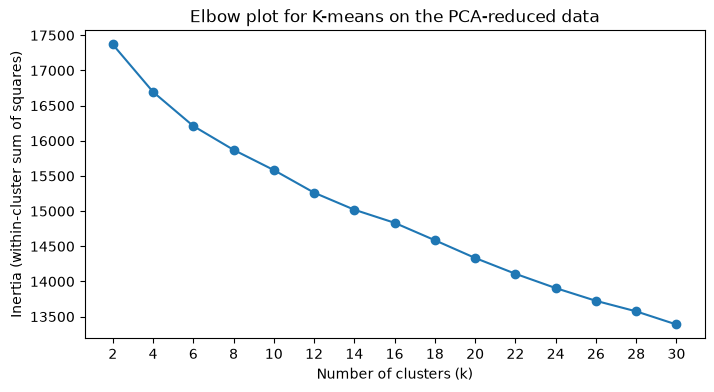

In [14]:
# --- Elbow plot: choosing k ---
# When you don't know how many clusters to ask for, the "elbow plot" can help.
# For each candidate k, we record the "inertia" — the total squared distance
# between each document and its assigned cluster centre. Lower is tighter clusters.
# We look for the k where adding more clusters stops helping much (the "elbow").

inertias = []                       # will store one inertia value per k
k_values = range(2, 31, 2)         # try k = 2, 4, 6, ..., 30 (step by 2 to save time)

for k in k_values:
    km = KMeans(n_clusters=k, n_init=4, random_state=SEED)  # n_init=4 (not 10) to keep the loop quick
    km.fit(X_norm)                  # run K-means on the normalised PCA data
    inertias.append(km.inertia_)   # store this k's inertia

# Plot the results
plt.figure(figsize=(8, 4))
plt.plot(k_values, inertias, marker='o')  # line plot with a dot at each k
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.title('Elbow plot for K-means on the PCA-reduced data')
plt.xticks(list(k_values))               # show every k value on the x-axis
plt.show()

Real elbow plots are rarely as clean as textbook ones. With 20 partly overlapping groups, no particular *k* stands out as natural. In practice you would try several values and inspect the clusters each time. We stay with `k=20` to compare against 4.1.

In [ ]:
# --- K-means on the PCA-reduced, normalised data ---
# Same algorithm as before, but now working on 100 dimensions instead of 21k.
# This should produce better clusters because PCA removed noise and normalisation
# made document length irrelevant.

km_pca = KMeans(n_clusters=20, n_init=10, random_state=SEED)  # same settings as in 4.1
clusters_pca = km_pca.fit_predict(X_norm)  # assign each document to one of 20 clusters
# (we have a different clustering solution now)
print("Documents per cluster:")
print(pd.Series(clusters_pca).value_counts().sort_index())  # count documents per cluster

Documents per cluster:
0     1466
1      643
2     1117
3      621
4      778
5      630
6      501
7     1300
8      616
9     1107
10     533
11     537
12    1253
13     819
14    1112
15     722
16    2631
17     475
18     485
19     540
Name: count, dtype: int64


One subtlety. The centres of these clusters live in PCA-space, not word-space, so we cannot read top words from them directly. PCA transformations can be reversed, however; `inverse_transform` maps each centre back into word-space.

In [16]:
# --- Interpret PCA-space clusters by mapping centres back to word-space ---
# The cluster centres live in PCA-space (100 dimensions), not word-space (21k words),
# so we can't read top words from them directly. But PCA is reversible:
# inverse_transform converts each centre back into word-space so we can use top_terms().

centres_in_word_space = pca.inverse_transform(km_pca.cluster_centers_)  # (20 clusters, 21k words)

print("Top words per cluster (PCA-reduced):\n")
for i, centre in enumerate(centres_in_word_space):  # loop over each cluster's word-space centre
    print(f"Cluster {i:>2}: {top_terms(centre, feature_names)}")

Top words per cluster (PCA-reduced):

Cluster  0: ax, cheers, kent, ground, dod, __, water, _____
Cluster  1: think, don, people, wrong, moral, thought, right, really
Cluster  2: gun, people, government, fbi, batf, koresh, law, guns
Cluster  3: israel, jews, armenian, israeli, arab, jewish, armenians, arabs
Cluster  4: just, wondering, got, don, like, ll, thought, maybe
Cluster  5: windows, dos, os, ms, file, files, nt, run
Cluster  6: space, nasa, shuttle, launch, orbit, moon, earth, mission
Cluster  7: file, window, program, server, use, files, motif, graphics
Cluster  8: msg, medical, information, disease, health, doctor, food, drug
Cluster  9: christian, church, people, jesus, bible, christians, religion, believe
Cluster 10: edu, cs, university, mit, ftp, david, uiuc, email
Cluster 11: god, jesus, bible, christ, sin, faith, believe, lord
Cluster 12: card, monitor, mac, video, apple, bus, board, pc
Cluster 13: thanks, advance, hi, mail, know, info, does, looking
Cluster 14: game, te

## 5. Did we find real structure?

Time to reveal the labels we have been hiding. If our clusters correspond to the actual newsgroups, documents from one newsgroup should mostly end up in one cluster. A cross-tabulation shows this quite well.

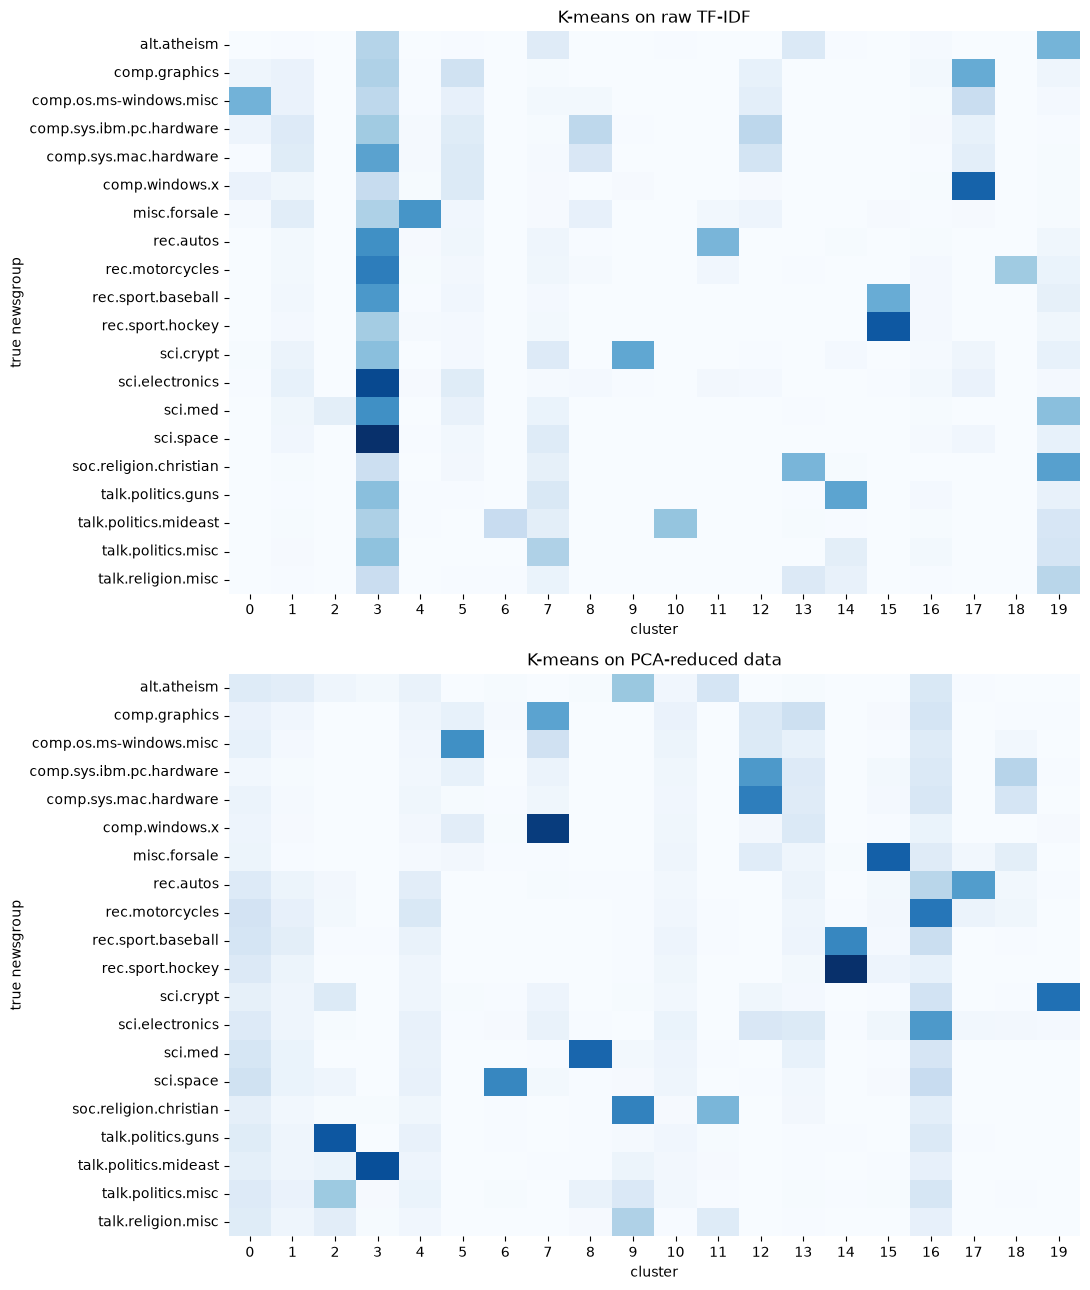

In [17]:
# --- Heatmaps: compare clusters against the true newsgroup labels ---
# A cross-tabulation counts how many documents from each true newsgroup (rows)
# ended up in each cluster (columns). If clusters match newsgroups well, each
# row should have one dark cell; if they don't, the colour is smeared across columns.
# We compare both clustering approaches side by side.

fig, (ax_raw, ax_pca) = plt.subplots(2, 1, figsize=(11, 13))  # two plots stacked vertically

# --- Heatmap for raw TF-IDF clusters ---
# Create cross-tabulation: rows = true newsgroups, columns = cluster assignments
crosstab_raw = pd.crosstab(
    pd.Series([label_names[l] for l in labels], name='true newsgroup'),  # human-readable newsgroup names
    pd.Series(clusters_raw, name='cluster'),                             # cluster numbers (0–19)
)
sns.heatmap(crosstab_raw, cmap='Blues', cbar=False, ax=ax_raw)  # plot as a blue heatmap
ax_raw.set_title('K-means on raw TF-IDF')

# --- Heatmap for PCA-reduced clusters ---
# same steps as above, for the second clustering
crosstab_pca = pd.crosstab(
    pd.Series([label_names[l] for l in labels], name='true newsgroup'),  # human-readable newsgroup names
    pd.Series(clusters_pca, name='cluster'),                             # cluster numbers (0-19)
)
sns.heatmap(crosstab_pca, cmap='Blues', cbar=False, ax=ax_pca)  # plot as a blue heatmap
ax_pca.set_title('K-means on PCA-reduced data')

plt.tight_layout()
plt.show()

Each row is a newsgroup; each column is a cluster the algorithm identified. A row with one dark cell means that newsgroup was recovered nearly intact; a row smeared across columns means the algorithm split it up or mixed it with others. Look for the patterns predicted in section 1: are the five `comp.*` rows sharing clusters? The three religion rows?

To summarise agreement in one number we use the **Adjusted Rand Index (ARI)**. It measures how often two labellings agree about whether a pair of documents belongs together, corrected for chance. An ARI of 1 means perfect agreement; 0 means no better than random guessing.

In [18]:
# --- Adjusted Rand Index: a single number for cluster quality ---
# ARI measures how well two sets of labels agree (our clusters vs the true newsgroups).
# 1.0 = perfect agreement, 0.0 = no better than random guessing.

ari_raw = adjusted_rand_score(labels, clusters_raw)   # compare true labels to raw TF-IDF clusters
ari_pca = adjusted_rand_score(labels, clusters_pca)   # compare true labels to PCA-reduced clusters

print(f"ARI, K-means on raw TF-IDF:        {ari_raw:.3f}")
print(f"ARI, K-means on PCA-reduced data:  {ari_pca:.3f}")

ARI, K-means on raw TF-IDF:        0.083
ARI, K-means on PCA-reduced data:  0.218


The combined route (dimentional reduction + clustering) scores clearly better than raw TF-IDF. Yet, these numbers are modest. This tells us that separating 20 newsgroups based on word frequency ('Bag of Words') alone is hard. This afternoon, we will apply a more sophisticated approach using embeddings. 

## 6. Your turn

**Exercise 1.** How much of the difficulty comes from the newsgroups being similar to each other? Rerun the pipeline on just **five clearly distinct groups** by passing `categories=['sci.space', 'sci.med', 'rec.sport.hockey', 'soc.religion.christian', 'talk.politics.mideast']` to `fetch_20newsgroups`. Use the PCA-reduced route with `k=5` and produce the cross-tabulation (with `annot=True`, since it is small enough to read now) and the ARI. How does the result compare?

In [ ]:
# your code here (Exercise 1). Here are some hints:
# - (You can use the same KMeans() function as above, but with a different number of clusters (n_clusters=5).
# - You can use the same Normalizer() function as above to normalise the PCA-reduced data before clustering.
# - You can use the same adjusted_rand_score() function as above to evaluate the clustering results against the true newsgroup labels.)

categories = ['sci.space', 'sci.med', 'rec.sport.hockey',
              'soc.religion.christian', 'talk.politics.mideast']


**Exercise 2.** Sticking with the full 20-group data, explore how sensitive the result is to your choices:

- vary the number of PCA components (try 10 and 300) and recompute the ARI;
- vary *k* (try 10 and 40) and recompute the ARI, then look at the heatmap for `k=10`.

What do you conclude about how much these settings matter?

In [ ]:
# your code here (Exercise 2)


---
### Solution, Exercise 1

In [ ]:
# --- Exercise 1 solution: cluster five clearly distinct newsgroups ---
# By picking newsgroups with very different vocabularies (space, medicine, hockey,
# religion, Middle East politics), we test whether the difficulty in the full
# 20-group analysis came from groups being too similar to each other.

# Step 1: fetch only the five chosen newsgroups
categories = ['sci.space', 'sci.med', 'rec.sport.hockey',
              'soc.religion.christian', 'talk.politics.mideast']
news5 = fetch_20newsgroups(subset='all', categories=categories,
                           remove=('headers', 'footers', 'quotes'), random_state=SEED)

# Step 2: filter out very short posts (same loop as section 1)
docs5 = []                                                     # texts we keep
labels5 = []                                                   # their labels
for doc, label in zip(news5.data, news5.target):               # posts and labels together
    if len(doc.strip()) > 50:                                  # long enough?
        docs5.append(doc)
        labels5.append(label)
labels5 = np.array(labels5)                                    # numpy array for comparisons

# Step 3: vectorise — turn text into TF-IDF numbers
vect5 = TfidfVectorizer(stop_words='english', min_df=5, max_df=0.9)  # same settings as before
X5_tfidf = vect5.fit_transform(docs5)                          # (documents, 21k words)

# Step 4: PCA — reduce from 21k dimensions to 100
pca5 = PCA(n_components=100, random_state=SEED)
X5_pca = pca5.fit_transform(X5_tfidf.toarray())                # (documents, 100 components)

# Step 5: normalise — rescale each vector to unit length
X5_norm = Normalizer().fit_transform(X5_pca)

# Step 6: K-means with k=5 (one cluster per newsgroup)
km5 = KMeans(n_clusters=5, n_init=10, random_state=SEED)
clusters5 = km5.fit_predict(X5_norm)                            # cluster label for each document

# Step 7: evaluate — how well do the five clusters match the five newsgroups?
print(f"ARI on the five distinct newsgroups: {adjusted_rand_score(labels5, clusters5):.3f}")

# Step 8: cross-tabulation heatmap (small enough to show actual numbers with annot=True)
crosstab5 = pd.crosstab(
    pd.Series([news5.target_names[l] for l in labels5], name='true newsgroup'),
    pd.Series(clusters5, name='cluster'),
)
plt.figure(figsize=(7, 4))
sns.heatmap(crosstab5, annot=True, fmt='d', cmap='Blues', cbar=False)  # annot=True prints counts in cells
plt.title('Five distinct newsgroups vs five K-means clusters')
plt.tight_layout()
plt.show()

The ARI jumps well above the 20-group result, and the heatmap shows most groups recovered cleanly. So much of the earlier difficulty came from the collection itself: when categories are distinct in vocabulary, simple unsupervised methods find them readily. How well clustering "works" is as much a property of the data as of the algorithm.

### Solution, Exercise 2

In [ ]:
# --- Exercise 2a: vary the number of PCA components ---
# Does it matter whether we keep 10, 100, or 300 components?
# We hold k=20 constant and re-run the full pipeline for each setting.

for n_comp in [10, 100, 300]:
    pca_n = PCA(n_components=n_comp, random_state=SEED)        # create PCA with this many components
    X_reduced = pca_n.fit_transform(X_dense)                   # reduce the original 21k-d data
    X_n = Normalizer().fit_transform(X_reduced)                # normalise to unit length
    km_n = KMeans(n_clusters=20, n_init=10, random_state=SEED) # cluster into 20 groups
    cluster_labels = km_n.fit_predict(X_n)                     # get cluster assignment for each document
    ari = adjusted_rand_score(labels, cluster_labels)          # compare to true newsgroup labels
    print(f"{n_comp:>3} components: ARI = {ari:.3f}")

In [ ]:
# --- Exercise 2b: vary k (number of clusters) ---
# Does it matter whether we ask for 10, 20, or 40 clusters?
# We hold PCA at 100 components and use the normalised data from earlier (X_norm).

for k in [10, 20, 40]:
    km_k = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    cluster_labels = km_k.fit_predict(X_norm)                  # cluster the normalised PCA data
    ari = adjusted_rand_score(labels, cluster_labels)          # compare to true labels
    print(f"k = {k:>2}: ARI = {ari:.3f}")

# --- Heatmap for k=10 ---
# With only 10 clusters for 20 newsgroups, some groups must be merged.
# The heatmap shows which newsgroups end up sharing a cluster.
km10 = KMeans(n_clusters=10, n_init=10, random_state=SEED)
clusters_10 = km10.fit_predict(X_norm)                         # assign documents to 10 clusters

crosstab10 = pd.crosstab(
    pd.Series([label_names[l] for l in labels], name='true newsgroup'),  # row per newsgroup
    pd.Series(clusters_10, name='cluster'),                              # column per cluster
)
plt.figure(figsize=(8, 6))
sns.heatmap(crosstab10, cmap='Blues', cbar=False)
plt.title('All 20 newsgroups vs 10 K-means clusters')
plt.tight_layout()
plt.show()

The number of components matters: *fewer* components did better here. Cutting seems to remove more noise, and the broad topics still fit in a few dimensions. The choice of *k* shifts the ARI less, and the k=10 heatmap shows the merges are somewhat sensible (related newsgroups pooled together). Settings like these are called **hyperparameters**. 

**Frustratingly, unsupervised learning normally offers little by way of accuracy score to tune them against; you choose them through diagnostics (elbow plots, variance curves) and by checking that the output is interpretable and useful. This is often an inherently qualitative exercise.** 

---

## Looking ahead to this afternoon

This morning's pipeline — represent the texts as vectors > reduce the dimensionality > cluster the result > read top words per cluster — is actually the same recipe behind **BERTopic**, which we will explore after lunch. BERTopic 'upgrades' every ingredient (transformer embeddings instead of of bag-of-words, UMAP instead of PCA, HDBSCAN instead of K-means) and packages them into a framework.